In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [2]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "analysis/"
files = os.listdir(excel_dir_path)
files = sorted(files)

rename_map = {
    "Nodes-Number of edge.": "Nodes-Edges",
    "Nodes-Number of edge. (Fitting)":"Nodes-Edges(Fit)",
    "Nodes-Average degree":"Nodes-Degree",
    "Nodes-Average degree (Fitting)":"Nodes-Degree(Fit)",
    "Nodes-Network diamet.":"Nodes-Diameter",
    "Nodes-Network diamet. (Fitting)":"Nodes-Diameter(Fit)",
    "Nodes-Graph density":"Nodes-Density",
    "Nodes-Graph density (Fitting)":"Nodes-Density(Fit)",
    "Nodes-Average betwee.":"Nodes-BC",
    "Nodes-Average betwee. (Fitting)":"Nodes-BC(Fit)",
    "Nodes-Average eigenv.":"Nodes-EC",
    "Nodes-Average eigenv. (Fitting)":"Nodes-EC(Fit)",
    "Nodes-Average closen.":"Nodes-CC",
    "Nodes-Average closen. (Fitting)":"Nodes-CC(Fit)",
    "Nodes-Assortativity .":"Nodes-ASC",
    "Nodes-Assortativity . (Fitting)":"Nodes-ASC(Fit)",
    "Nodes-Average cluste.":"Nodes-ACC",
    "Nodes-Average cluste. (Fitting)":"Nodes-ACC(Fit)",
    "Nodes-Global efficie.":"Nodes-GE",
    "Nodes-Global efficie. (Fitting)":"Nodes-GE(Fit)",
    "Nodes-Wiener Index":"Nodes-WI",
    "Nodes-Wiener Index (Fitting)":"Nodes-WI(Fit)",
}

all_sheets = {}
for a_file in files:
    if a_file.endswith(allowed_ext):
        # Get the Excel file and load its contents
        file_path = os.path.join(excel_dir_path, a_file)
        file_sheets = pd.read_excel(file_path, sheet_name=None)

        # Append Excel data to one place
        for sheet_name, df in file_sheets.items():
            # Rename it if sheet_name exists in mapping
            new_name = rename_map.get(sheet_name, sheet_name)

            # Add Material column with file name (without extension)
            df = df.copy()
            df["Material"] = os.path.splitext(a_file)[0]

            if new_name not in all_sheets:
                all_sheets[new_name] = []  # initialize list
            all_sheets[new_name].append(df)

# Concatenate each list of DataFrames into one
for sheet_name in all_sheets:
    all_sheets[sheet_name] = pd.concat(all_sheets[sheet_name], ignore_index=True)



In [3]:
df_sgt = all_sheets['SGT Descriptors']
# df_sgt.columns = df_sgt.iloc[0]
# df_sgt = df_sgt[1:]
# df_sgt = df_sgt.dropna(axis=1)

param_rename_map = {
    "Number of nodes": "Nodes",
    "Number of edges": "Edges",
    "Network diameter": "Diameter",
    "Average edge angle (degrees)": "Avg. E. Angle",
    "Median edge angle (degrees)": "Med. E. Angle",
    "Graph density": "GD",
    "Average degree": "AD",
    "Global efficiency": "GE",
    "Wiener Index": "WI",
    "Assortativity coefficient": "ASC",
    "Average clustering coefficient": "ACC",
    "Average betweenness centrality": "BC",
    "Average eigenvector centrality": "EC",
    "Average closeness centrality": "CC",
}

# Rename Columns
# Apply replacements in the "Parameter" column
if "parameter" in df_sgt.columns:
    df_sgt["parameter"] = df_sgt["parameter"].replace(param_rename_map)

KeyError: 'SGT Descriptors'

In [20]:
# Ensure the value columns exist
value_cols = ["value-1", "value-2", "value-3", "value-4"]

if all(col in df_sgt.columns for col in value_cols):
    df_sgt["Avg."] = df_sgt[value_cols].astype(float).mean(axis=1)
    df_sgt["Std. Dev."] = df_sgt[value_cols].astype(float).std(axis=1)

In [5]:
# Filter the relevant materials and parameters
materials = ['ARImGr0S2', 'ARImGr0S3', 'ARImGr0S8']
material_names = ['Sample S2', 'Sample S3', 'Sample S8']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

# Filter and pivot
# filtered_df = df_sgt[df_sgt['Material'].isin(materials) & df_sgt['Parameter'].isin(parameters)]
pivot_avg = df_sgt.pivot(index='Material', columns='parameter', values='Avg.')
pivot_std = df_sgt.pivot(index='Material', columns='parameter', values='Std. Dev.')

# Ensure consistent parameter order
pivot_avg = pivot_avg[parameters]
pivot_std = pivot_std[parameters]

#print(filtered_df)
print(f"Avg Table:\n{pivot_avg}")

NameError: name 'df_sgt' is not defined

NameError: name 'pivot_avg' is not defined

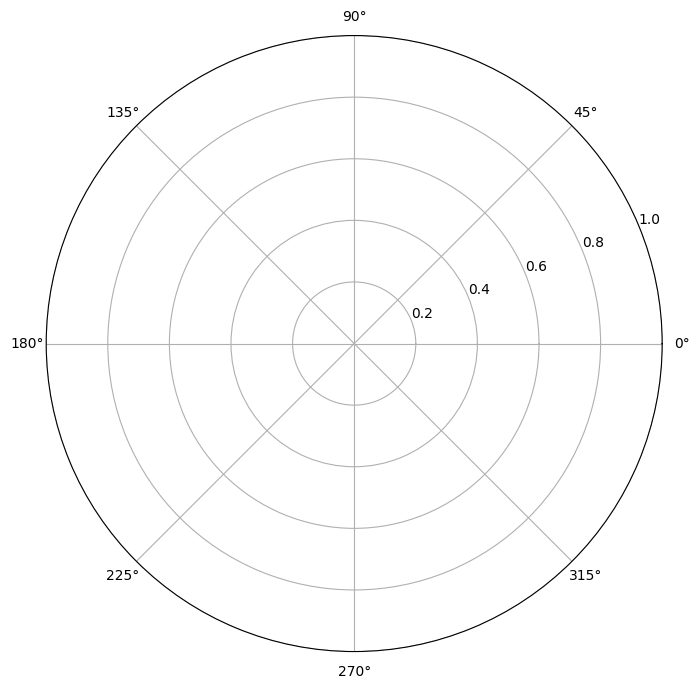

In [8]:
# Radar chart setup
labels = parameters
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
labels += [labels[0]]  # close the loop
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each material
for mat in materials:
    values = pivot_avg.loc[mat].tolist()
    values += [values[0]]  # close the loop

    errors = pivot_std.loc[mat].tolist()
    errors += [errors[0]]

    ax.plot(angles, values, label=mat)
    ax.fill_between(angles,
                    np.array(values) - np.array(errors),
                    np.array(values) + np.array(errors),
                    alpha=0.1)

# Final touches
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
ax.set_title("Spider Plot with Std. Dev. Error Bands", fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
fig.savefig('analysis/plots/spider.png', dpi=300)
plt.show()

/Users/owuorjnr/owProjects/StructuralGT/.venv_sgt/lib/python3.13/site-packages/scipy/stats/_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


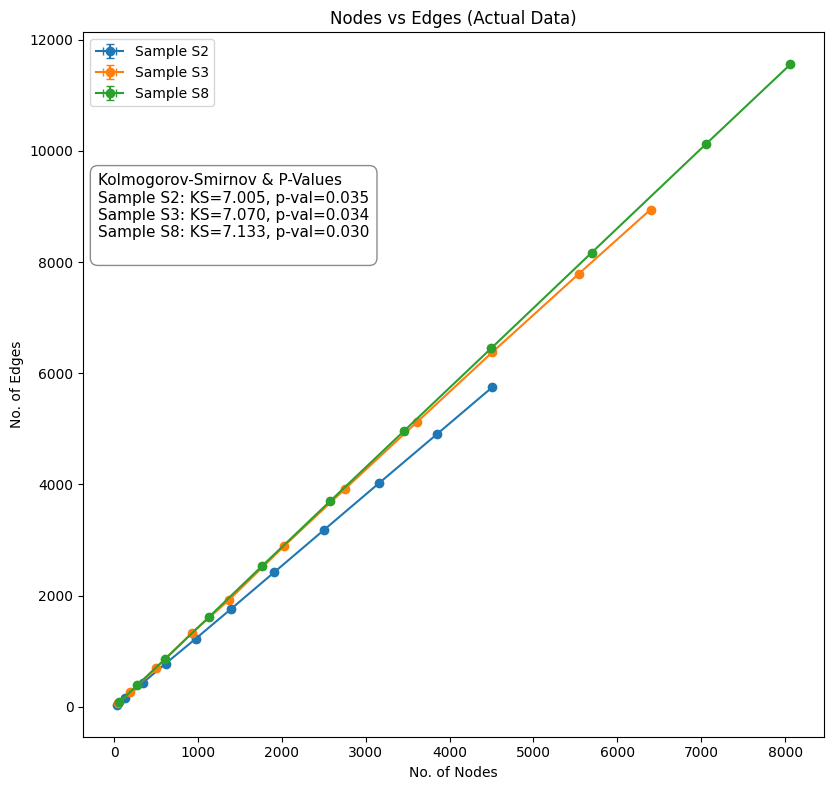

In [6]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_edges[df_edges['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.3f}, p-val={res.pvalue:.3f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('No. of Edges')
ax2.set_title('Nodes vs Edges (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.02, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_edges.png', dpi=300)
plt.show()

Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


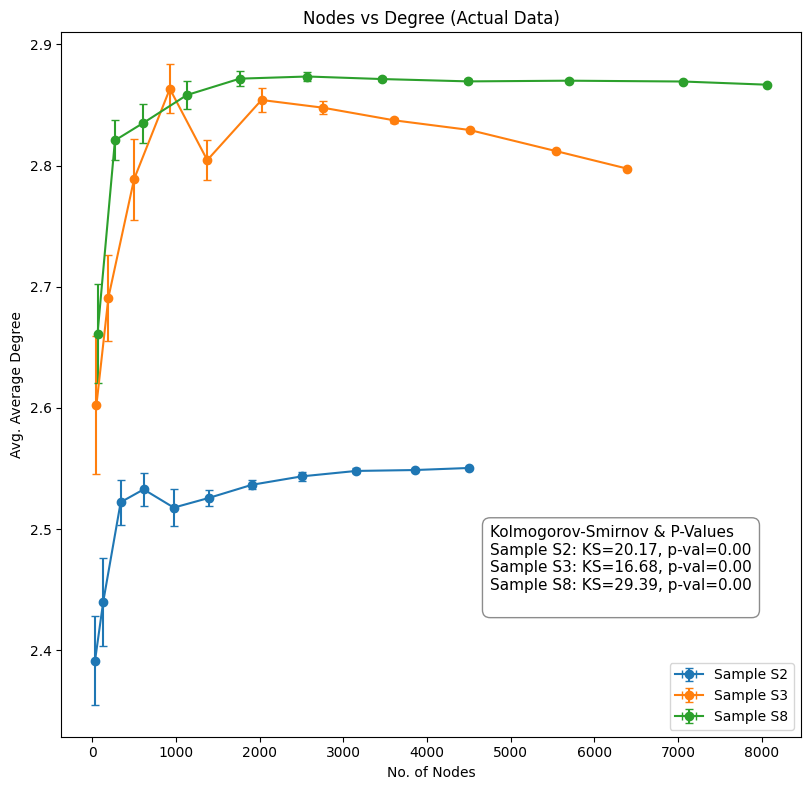

In [7]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_deg[df_deg['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Average Degree')
ax2.set_title('Nodes vs Degree (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.3, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_deg.png', dpi=300)
plt.show()

/Users/owuorjnr/owProjects/StructuralGT/.venv_sgt/lib/python3.13/site-packages/scipy/stats/_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


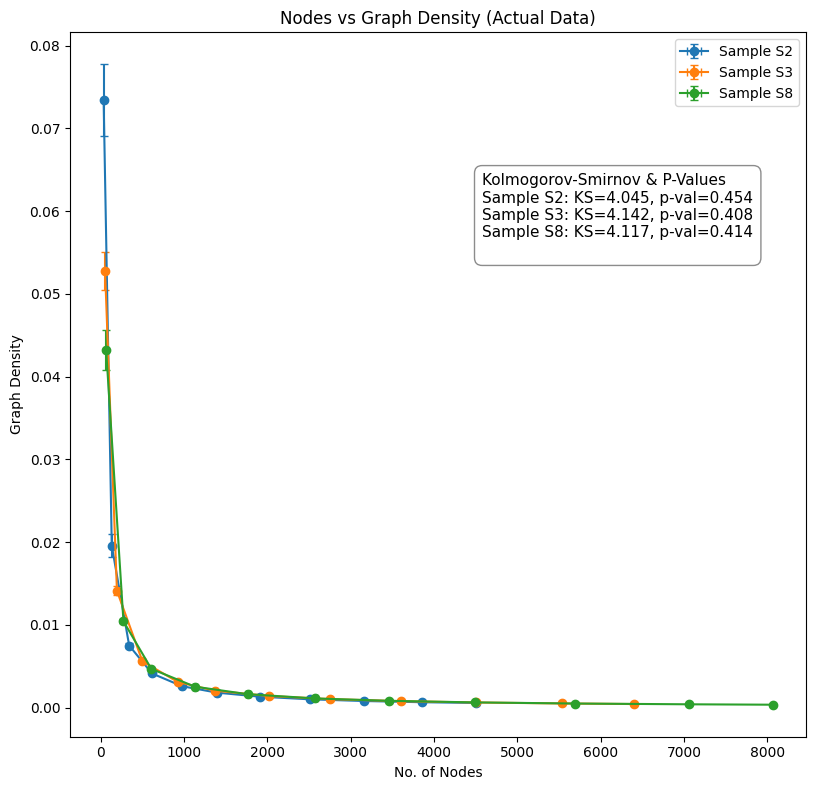

In [10]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']



fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_dens[df_dens['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.3f}, p-val={res.pvalue:.3f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Graph Density')
ax2.set_title('Nodes vs Graph Density (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.56, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_gd.png', dpi=300)
plt.show()

Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


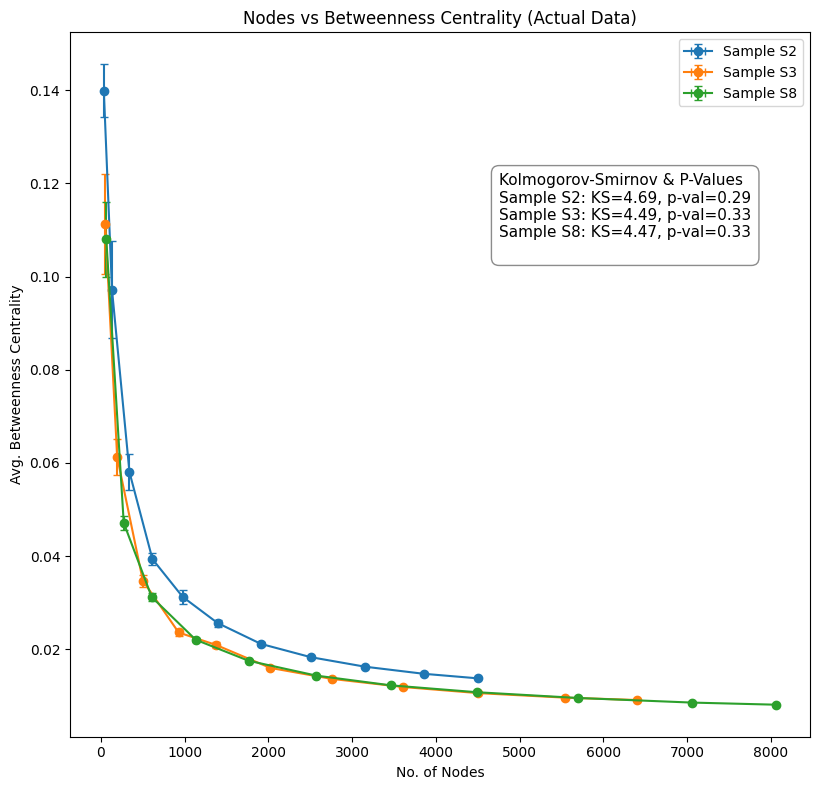

In [11]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_bet[df_bet['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Betweenness Centrality')
ax2.set_title('Nodes vs Betweenness Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_bc.png', dpi=300)
plt.show()

/Users/owuorjnr/owProjects/StructuralGT/.venv_sgt/lib/python3.13/site-packages/scipy/stats/_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


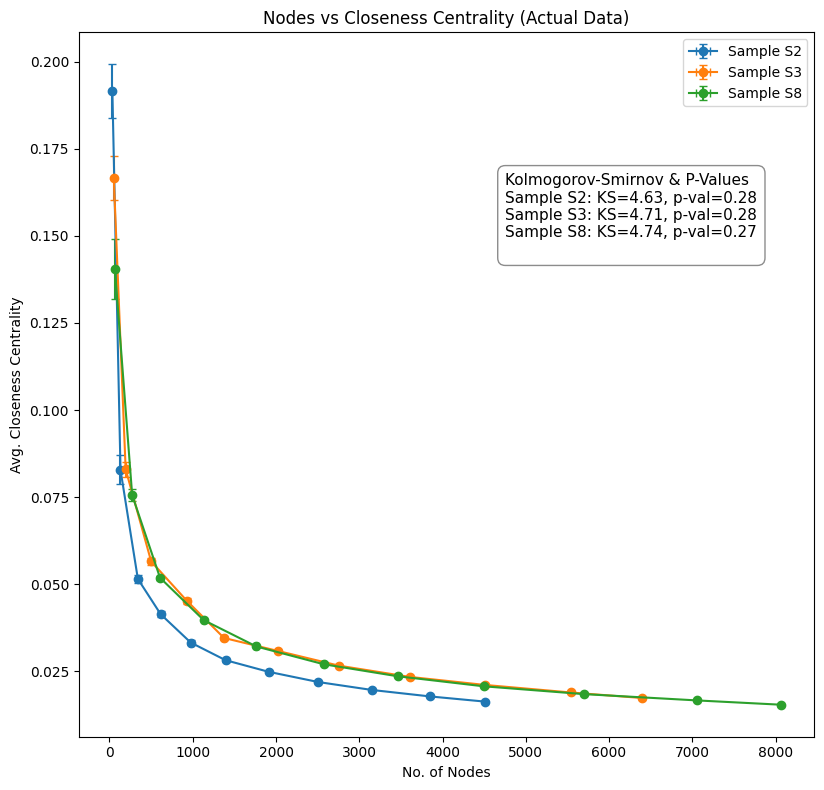

In [12]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_clo[df_clo['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Closeness Centrality')
ax2.set_title('Nodes vs Closeness Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_cc.png', dpi=300)
plt.show()

/Users/owuorjnr/owProjects/StructuralGT/.venv_sgt/lib/python3.13/site-packages/scipy/stats/_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


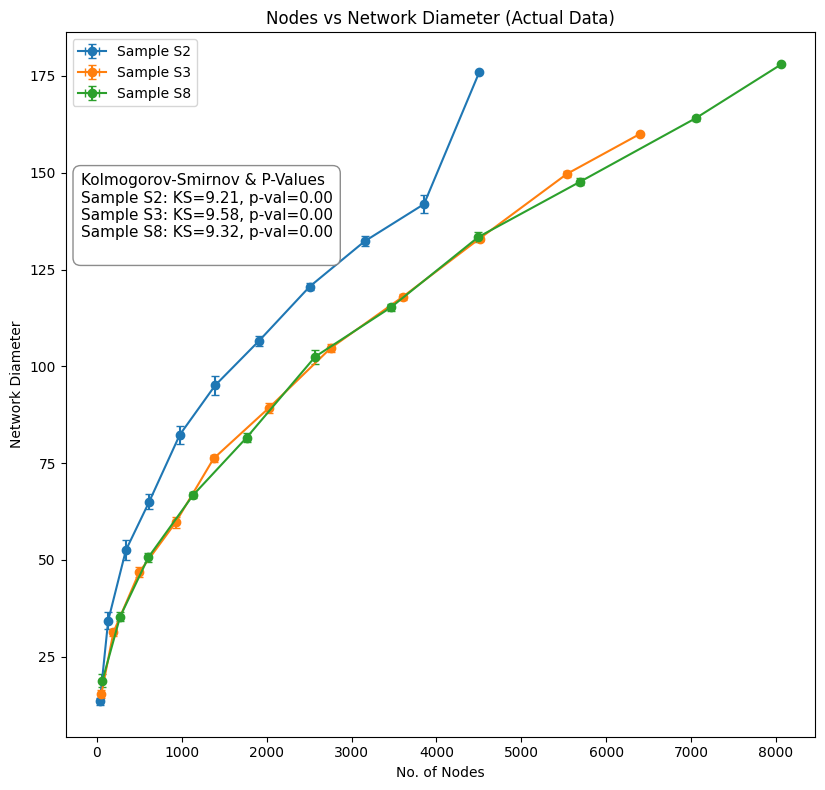

In [13]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']


fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_dia[df_dia['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Network Diameter')
ax2.set_title('Nodes vs Network Diameter (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.02, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_nd.png', dpi=300)
plt.show()

/Users/owuorjnr/owProjects/StructuralGT/.venv_sgt/lib/python3.13/site-packages/scipy/stats/_resampling.py:960: RuntimeWarning: invalid value encountered in scalar subtract
  cmps = null_distribution >= observed - gamma


Sample S2 (exponential fit): KS=inf, p-value=0.00
Sample S3 (exponential fit): KS=inf, p-value=0.00
Sample S8 (exponential fit): KS=inf, p-value=0.00


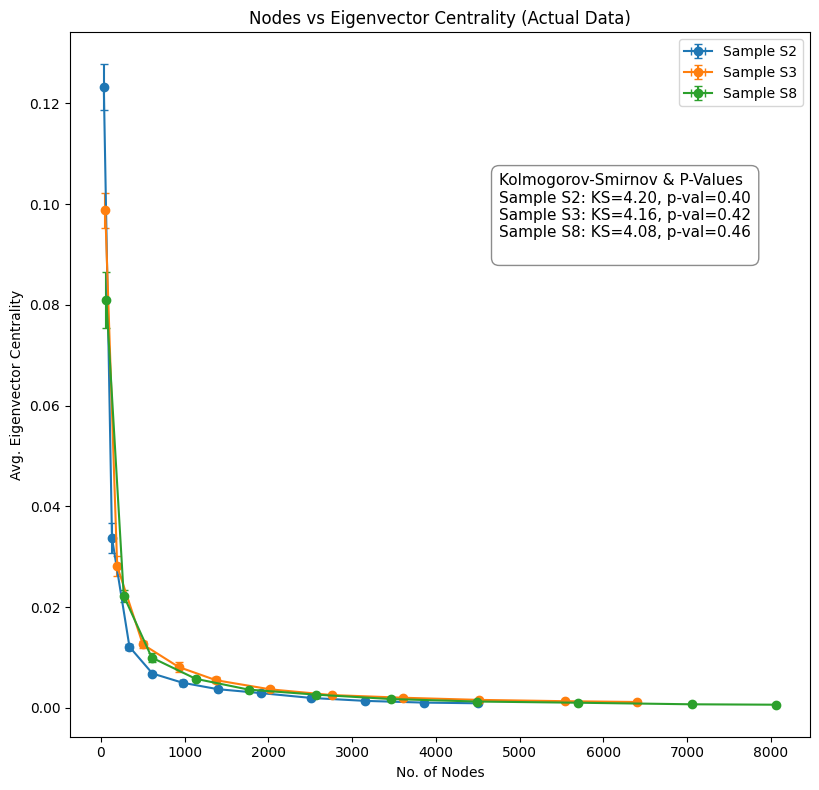

In [9]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']




fig = plt.figure(figsize=(16, 8))
ax2 = fig.add_subplot(1, 2, 2)
fit_text = "Kolmogorov-Smirnov & P-Values\n"
for i, sample in enumerate(materials):
    df_sample = df_eig[df_eig['Material'] == sample].copy()
    res = stats.goodness_of_fit(stats.powerlaw, df_sample['y-avg'].to_numpy())
    fit_text += f"{material_names[i]}: KS={res.statistic:.2f}, p-val={res.pvalue:.2f}\n"
    res_2 = stats.goodness_of_fit(stats.expon, df_sample['y-avg'].to_numpy())
    print(f"{material_names[i]} (exponential fit): KS={res_2.statistic:.2f}, p-value={res_2.pvalue:.2f}")
    ax2.errorbar(
        df_sample['x-avg'],
        df_sample['y-avg'],
        yerr=df_sample['y-std'],
        xerr=df_sample['x-std'],
        label=material_names[i],
        marker='o',
        capsize=3,
        linestyle='-'
    )

ax2.set_xlabel('No. of Nodes')
ax2.set_ylabel('Avg. Eigenvector Centrality')
ax2.set_title('Nodes vs Eigenvector Centrality (Actual Data)')
ax2.legend()
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax2.text(.58, 0.8, fit_text, transform=ax2.transAxes, fontsize=11,
         verticalalignment='top', bbox=props)
plt.grid(False)
plt.tight_layout()
fig.savefig('analysis/plots/nodes_ec.png', dpi=300)
plt.show()